In [ ]:
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
import numpy as np
import pytorch_lightning as pl
from pytorch_lightning.strategies import DDPStrategy
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger
from dataprocess_dgl import Mesh2a1vDGL, create_dataloaders, collate_cc_as_node, collate_cc_as_edge, collate_graphomer, collate_cc_as_edge_pe
from dataprocess_pyg import Mesh2a1vPYG
from utils import plot_acc_w_segment
from ogb.graphproppred import Evaluator
from model import GNNGlitch, DeepGCNGlitch, GraphomerGlitch, SiGTGlitch, SiGTGlitchPE, GraphGPSGlitch, SGFormerGlitch
import pickle

In [ ]:
# Glitch only for victim nodes.
model_name = 'Graphomer'
task = 'glitch'
mode = 'segment'  # 'segment' or 'sink'
raw_data = f'./{task}'
exp_name = f'{mode}-2A1V-{model_name}'
batch_size=256
num_epochs = 100

if model_name == 'NormGNN':
    root = f'./{task}_dataset/DGL/{mode}/left'
    os.makedirs(root, exist_ok=True)
    dataset = Mesh2a1vPYG(root=root, raw_data=raw_data, directed=False, accumulation=False, task=task, timing=mode, cc_pattern='as_edge')
    train_loader, valid_loader, test_loader = create_dataloaders(dataset, batch_size, 'PYG')
    model = GNNGlitch(in_ch=1, out_ch=4, hidden_channels=128, batch_size=batch_size, gnn_type='gcn', lr=0.002)

elif model_name == 'DeepGCN':
    root = f'./{task}_dataset/DGL/{mode}/left'
    os.makedirs(root, exist_ok=True)
    dataset = Mesh2a1vPYG(root=root, raw_data=raw_data, directed=False, accumulation=False, task=task, timing=mode, cc_pattern='as_edge')
    train_loader, valid_loader, test_loader = create_dataloaders(dataset, batch_size, 'PYG')
    model = DeepGCNGlitch(in_ch=1,out_ch=4,hidden_channels=64,conv_layer_num=20,batch_size=batch_size,lr=0.001,dropout=0.1,block_type='res+',)

elif model_name == 'Graphomer':
    root = f'./{task}_dataset/DGL/segment/left'
    os.makedirs(root, exist_ok=True)
    dataset = Mesh2a1vDGL(root=root, raw_data=raw_data, directed=False, accumulation=False, task=task, timing='segment', cc_pattern='as_edge')
    train_loader, valid_loader, test_loader = create_dataloaders(dataset, batch_size, 'DGL', collate_fn=collate_graphomer)
    total_updates = 33000 * num_epochs / batch_size
    warmup_updates = total_updates * 0.16
    model = GraphomerGlitch(total_updates=total_updates, warmup_updates=warmup_updates, lr=1e-4, weight_decay=0.0, eps=1e-8, batch_size=batch_size, mode=mode)

elif model_name == "SGFormer":
    root = f'./{task}_dataset/DGL/{mode}/left_pe_5'
    os.makedirs(root, exist_ok=True)
    cfg = {
        'posenc_RWSE': {
            'enable': True,
            'kernel': {
                'times_func': range(1, 17),
                'times': list(range(1, 17)),  
            },
            'model': 'Linear',
            'dim_pe': 16,
            'raw_norm_type': 'BatchNorm'
        }
    }
    dataset = Mesh2a1vPYG(root=root, raw_data=raw_data, directed=False, accumulation=False, task=task, timing=mode, cc_pattern='as_edge', pe=True, pe_type=["RWSE"], cfg=cfg)
    train_loader, valid_loader, test_loader = create_dataloaders(dataset, batch_size, 'PYG')
    model = SGFormerGlitch(channels=64, pe_dim=16, num_layers=4, batchsize=batch_size)

elif model_name == 'GraphGPS':
    #Support PE: 'LapPE', 'EquivStableLapPE', 'SignNet', 'RWSE', 'HKdiagSE', 'HKfullPE', 'ElstaticSE'
    # pe_type can be a combination, e.g. 'eigen+rw_landing'
    root = f'./{task}_dataset/DGL/{mode}/left_EqlapPE8'
    os.makedirs(root, exist_ok=True)
    cfg = {
        "posenc_EquivStableLapPE": {
            "enable": True,
            "eigen": {
                "laplacian_norm": "none",
                "eigvec_norm": "L2",
                "max_freqs": 8
            },
            "raw_norm_type": "none"
        }
    }
    dataset = Mesh2a1vPYG(root=root, raw_data=raw_data, directed=False, accumulation=False, task=task, timing={mode}, cc_pattern='as_edge', pe=True, pe_type=["EquivStableLapPE"], cfg=cfg)
    train_loader, valid_loader, test_loader = create_dataloaders(dataset, batch_size, 'PYG')
    model = GraphGPSGlitch(channels=64, input_dim=8, pe_dim=16, num_layers=10, attn_type='multihead', batchsize=batch_size)

elif model_name == 'SiGT':
    root = f'./{task}_dataset/DGL/segment/left'
    os.makedirs(root, exist_ok=True)
    dataset = Mesh2a1vDGL(root=root, raw_data=raw_data, directed=False, accumulation=False, task=task, timing='segment', cc_pattern='as_edge')
    train_loader, valid_loader, test_loader = create_dataloaders(dataset, batch_size, 'DGL', collate_fn=collate_cc_as_edge)
    total_updates = 33000 * num_epochs / batch_size
    warmup_updates = total_updates * 0.16
    model = SiGTGlitch(node_encoding='gnn', total_updates=total_updates, warmup_updates=warmup_updates, lr=8e-4, weight_decay=0.0, eps=1e-8, batch_size=batch_size, mode=mode)

/home/csgrad/yhu/projs/crosstalk/dataprocess_pyg.py:279: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.data, self.slices = torch.load(self.processed_paths[0])


187309


/home/csgrad/yhu/miniconda3/envs/crosstalk/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [ ]:
def acc_seg(model_name, model, checkpoint, tag):
    checkpoint = torch.load(checkpoint)
    state_dict = checkpoint['state_dict']
    loaded_model = model
    loaded_model.load_state_dict(state_dict, strict=False)
    loaded_model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    loaded_model = loaded_model.to(device)
    segment_agg1_acc = {}
    segment_agg2_acc = {}
    segment_vict_acc = {}
    vmax_acc = {}
    tw_acc = {}
    if model_name in ['NormGNN', 'DeepGCN']:
        with torch.no_grad():
            for batch in test_loader:   
                batch = batch.to(device)
                segment = batch.segment.item()
                vic_mask = batch.vic_mask.bool()
                out = loaded_model(batch.x, batch.edge_index, batch.edge_attr)
                
                mask_out = out[vic_mask]
                mask_label = batch.label[vic_mask]

                def compute_accuracy(pred, label):
                    mask = label != 0
                    pred_masked = pred[mask]
                    label_masked = label[mask]
                    acc = 100 - torch.mean(torch.abs(pred_masked - label_masked) / torch.abs(label_masked)) * 100
                    return acc

                vmax_p_acc = compute_accuracy(mask_out[:, 0], mask_label[:, 0])
                tw_p_acc = compute_accuracy(mask_out[:, 1], mask_label[:, 1])
                vmax_n_acc = compute_accuracy(mask_out[:, 2], mask_label[:, 2])
                tw_n_acc = compute_accuracy(mask_out[:, 3], mask_label[:, 3])
                if segment not in tw_acc:
                    tw_acc[segment] = []
                else:
                    tw_acc[segment].append(tw_p_acc.item())
                if segment not in vmax_acc:
                    vmax_acc[segment] = []
                else:
                    vmax_acc[segment].append(vmax_p_acc.item())
                        
        plot_acc_w_segment(tw_acc, f'{task}_results/acc_seg/{exp_name}/segment_{tag}_tw_acc.png')
        with open(f'{task}_results/acc_seg/{exp_name}/segment_{tag}_tw_acc.pkl', 'wb') as f:
            pickle.dump(tw_acc, f)
        plot_acc_w_segment(vmax_acc, f'{task}_results/acc_seg/{exp_name}/segment_{tag}_vmax_acc.png')
        with open(f'{task}_results/acc_seg/{exp_name}/segment_{tag}_vmax_acc.pkl', 'wb') as f:
            pickle.dump(vmax_acc, f)
            
    elif model_name == 'Graphomer':
        with torch.no_grad():
            for batch in test_loader:
                (
                    node_feat,
                    node_label,
                    node_mask,
                    node_vic_mask,
                    node_agg1_mask,
                    node_agg2_mask,
                    sink_mask,
                    sink_vic_mask,
                    sink_agg1_mask,
                    sink_agg2_mask,
                    in_degree,
                    out_degree,
                    attn_mask,
                    path_data,
                    dist
                ) = batch
                node_feat = node_feat.to(device)
                node_label = node_label.to(device)
                node_mask = node_mask.to(device)
                node_vic_mask = node_vic_mask.to(device)
                node_agg1_mask = node_agg1_mask.to(device)
                node_agg2_mask = node_agg2_mask.to(device)
                sink_mask = sink_mask.to(device)
                sink_vic_mask = sink_vic_mask.to(device)
                sink_agg1_mask = sink_agg1_mask.to(device)
                sink_agg2_mask = sink_agg2_mask.to(device)
                attn_mask = attn_mask.to(device)
                in_degree = in_degree.to(device)
                out_degree = out_degree.to(device)
                path_data = path_data.to(device)
                dist = dist.to(device)
                out = loaded_model(
                    node_feat,
                    in_degree,
                    out_degree,
                    path_data,
                    dist,
                    attn_mask=attn_mask,
                )
                out = out.squeeze(dim=-1)
                node_label = node_label.squeeze(dim=-1)
                node_num = node_feat.shape[1]
                segment = int(node_num/3-1)
                
                node_vic_mask[node_vic_mask == -1] = 0
                vic_mask = node_vic_mask.bool()
        
                mask_out = out[vic_mask] 
                mask_label = node_label[vic_mask]
                def compute_accuracy(pred, label):
                    mask = label != 0
                    pred_masked = pred[mask]
                    label_masked = label[mask]
                    acc = 100 - torch.mean(torch.abs(pred_masked - label_masked) / torch.abs(label_masked)) * 100
                    return acc
                vmax_p_acc = compute_accuracy(mask_out[:, 0], mask_label[:, 0])
                tw_p_acc   = compute_accuracy(mask_out[:, 1], mask_label[:, 1])
                vmax_n_acc = compute_accuracy(mask_out[:, 2], mask_label[:, 2])
                tw_n_acc   = compute_accuracy(mask_out[:, 3], mask_label[:, 3])
                if segment not in tw_acc:
                    tw_acc[segment] = []
                else:
                    tw_acc[segment].append(tw_p_acc.item())
                if segment not in vmax_acc:
                    vmax_acc[segment] = []
                else:
                    vmax_acc[segment].append(vmax_p_acc.item())
                
        os.makedirs(f"{task}_results/acc_seg/{exp_name}", exist_ok=True)
        plot_acc_w_segment(tw_acc, f'{task}_results/acc_seg/{exp_name}/segment_{tag}_tw_acc.png')
        with open(f'{task}_results/acc_seg/{exp_name}/segment_{tag}_tw_acc.pkl', 'wb') as f:
            pickle.dump(tw_acc, f)
        plot_acc_w_segment(vmax_acc, f'{task}_results/acc_seg/{exp_name}/segment_{tag}_vmax_acc.png')
        with open(f'{task}_results/acc_seg/{exp_name}/segment_{tag}_vmax_acc.pkl', 'wb') as f:
            pickle.dump(vmax_acc, f)
    elif model_name in ['GraphGPS', 'SGFormer']:
        with torch.no_grad():
            for batch in test_loader:   
                batch = batch.to(device)
                segment = batch.segment.item()
                vic_mask = batch.vic_mask.bool()
                out = loaded_model(batch.x, batch.pestat_RWSE, batch.edge_index, batch.edge_attr, batch.batch)
                
                mask_out = out[vic_mask]
                mask_label = batch.label[vic_mask]

                def compute_accuracy(pred, label):
                    mask = label != 0
                    pred_masked = pred[mask]
                    label_masked = label[mask]
                    acc = 100 - torch.mean(torch.abs(pred_masked - label_masked) / torch.abs(label_masked)) * 100
                    return acc

                vmax_p_acc = compute_accuracy(mask_out[:, 0], mask_label[:, 0])
                tw_p_acc = compute_accuracy(mask_out[:, 1], mask_label[:, 1])
                vmax_n_acc = compute_accuracy(mask_out[:, 2], mask_label[:, 2])
                tw_n_acc = compute_accuracy(mask_out[:, 3], mask_label[:, 3])
                if segment not in tw_acc:
                    tw_acc[segment] = []
                else:
                    tw_acc[segment].append(tw_p_acc.item())
                if segment not in vmax_acc:
                    vmax_acc[segment] = []
                else:
                    vmax_acc[segment].append(vmax_p_acc.item())
                        
        plot_acc_w_segment(tw_acc, f'{task}_results/acc_seg/{exp_name}/segment_{tag}_tw_acc.png')
        with open(f'{task}_results/acc_seg/{exp_name}/segment_{tag}_tw_acc.pkl', 'wb') as f:
            pickle.dump(tw_acc, f)
        plot_acc_w_segment(vmax_acc, f'{task}_results/acc_seg/{exp_name}/segment_{tag}_vmax_acc.png')
        with open(f'{task}_results/acc_seg/{exp_name}/segment_{tag}_vmax_acc.pkl', 'wb') as f:
            pickle.dump(vmax_acc, f)
    else:
        with torch.no_grad():
            for batch in test_loader:
                (
                    bg,
                    bsg,
                    node_feat,
                    node_label,
                    node_mask,
                    node_vic_mask,
                    node_agg1_mask,
                    node_agg2_mask,
                    sink_mask,
                    sink_vic_mask,
                    sink_agg1_mask,
                    sink_agg2_mask,
                    # in_degree,
                    # out_degree,
                    attn_mask,
                    net_token_attn_mask,
                    path_data,
                    dist,
                    attn_net_A, 
                    attn_couple_A
                ) = batch
                bg = bg.to(device)
                bsg = bsg.to(device)
                node_feat = node_feat.to(device)
                node_label = node_label.to(device)
                node_mask = node_mask.to(device)
                node_vic_mask = node_vic_mask.to(device)
                node_agg1_mask = node_agg1_mask.to(device)
                node_agg2_mask = node_agg2_mask.to(device)
                sink_mask = sink_mask.to(device)
                sink_vic_mask = sink_vic_mask.to(device)
                sink_agg1_mask = sink_agg1_mask.to(device)
                sink_agg2_mask = sink_agg2_mask.to(device)
                attn_mask = attn_mask.to(device)
                net_token_attn_mask = net_token_attn_mask.to(device)
                path_data = path_data.to(device)
                dist = dist.to(device)
                attn_net_A = attn_net_A.to(device)
                attn_couple_A = attn_couple_A.to(device)
                out = loaded_model(
                    bg,
                    bsg,
                    node_feat,
                    # in_degree,
                    # out_degree,
                    path_data,
                    dist,
                    attn_net_A, 
                    attn_couple_A,
                    attn_mask=attn_mask,
                    net_attn_mask = net_token_attn_mask,
                )
                out = out.squeeze(dim=-1)
                node_label = node_label.squeeze(dim=-1)
                node_num = node_feat.shape[1]
                segment = int(node_num/3-1)
                
                node_vic_mask[node_vic_mask == -1] = 0
                vic_mask = node_vic_mask.bool()
        
                mask_out = out[vic_mask] 
                mask_label = node_label[vic_mask]
                def compute_accuracy(pred, label):
                    mask = label != 0
                    pred_masked = pred[mask]
                    label_masked = label[mask]
                    acc = 100 - torch.mean(torch.abs(pred_masked - label_masked) / torch.abs(label_masked)) * 100
                    return acc
                vmax_p_acc = compute_accuracy(mask_out[:, 0], mask_label[:, 0])
                tw_p_acc   = compute_accuracy(mask_out[:, 1], mask_label[:, 1])
                vmax_n_acc = compute_accuracy(mask_out[:, 2], mask_label[:, 2])
                tw_n_acc   = compute_accuracy(mask_out[:, 3], mask_label[:, 3])
                if segment not in tw_acc:
                    tw_acc[segment] = []
                else:
                    tw_acc[segment].append(tw_p_acc.item())
                if segment not in vmax_acc:
                    vmax_acc[segment] = []
                else:
                    vmax_acc[segment].append(vmax_p_acc.item())
                
        os.makedirs(f"{task}_results/acc_seg/{exp_name}", exist_ok=True)
        plot_acc_w_segment(tw_acc, f'{task}_results/acc_seg/{exp_name}/segment_{tag}_tw_acc.png')
        with open(f'{task}_results/acc_seg/{exp_name}/segment_{tag}_tw_acc.pkl', 'wb') as f:
            pickle.dump(tw_acc, f)
        plot_acc_w_segment(vmax_acc, f'{task}_results/acc_seg/{exp_name}/segment_{tag}_vmax_acc.png')
        with open(f'{task}_results/acc_seg/{exp_name}/segment_{tag}_vmax_acc.pkl', 'wb') as f:
            pickle.dump(vmax_acc, f)
    

/tmp/ipykernel_968651/2102973931.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint)


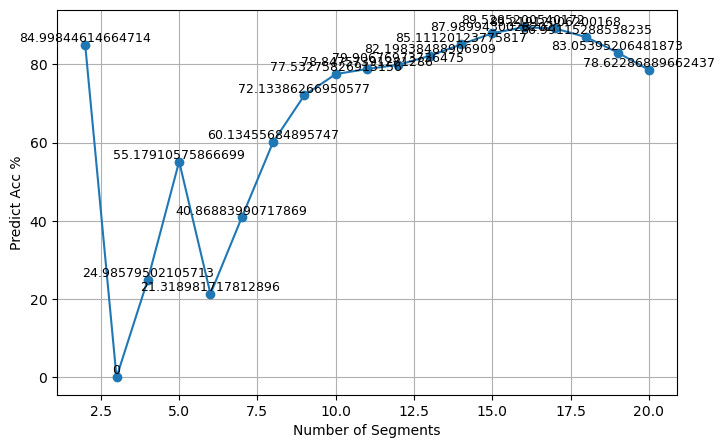

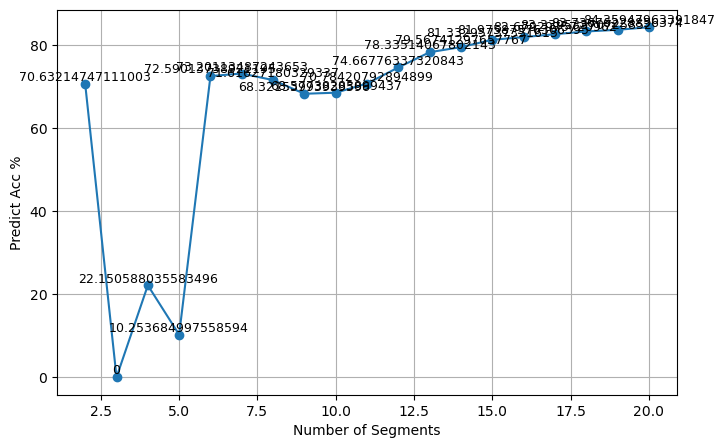

In [21]:
checkpoint = "glitch_logs/left/Segment-2A1V-SGFormer/version_0/checkpoints/epoch=23-val_loss=0.02.ckpt"
# checkpoint = "glitch_logs/left/Segment-2A1V-GraphGPS/5pe/checkpoints/epoch=21-val_loss=0.00.ckpt"
# checkpoint = "glitch_logs/left/Segment-2A1V-NormalGNN/deepGCN/checkpoints/epoch=59-val_loss=0.02.ckpt"
# checkpoint = "glitch_logs/left/Segment-2A1V-NormalGNN/GAT/checkpoints/epoch=26-val_loss=0.02.ckpt"
# checkpoint = "glitch_logs/left/Segment-2A1V-NormalGNN/GCN/checkpoints/epoch=26-val_loss=0.02.ckpt"
# checkpoint = "glitch_logs/left/Segment-2A1V-NormalGNN/GIN/checkpoints/epoch=21-val_loss=0.02.ckpt"
# checkpoint = "glitch_logs/left/Segment-2A1V-NormalGNN/SAGE/checkpoints/epoch=27-val_loss=0.02.ckpt"
# checkpoint = "glitch_logs/left/Segment-2A1V-Graphomer/VanillaGT/checkpoints/epoch=55-val_loss=0.01.ckpt"
# checkpoint = "glitch_logs/left/Segment-2A1V-Graphomer/CrossGT-SAGE/checkpoints/epoch=76-val_loss=0.00.ckpt"
# checkpoint = "glitch_logs/left/Segment-2A1V-Graphomer/CrossGT-GIN/checkpoints/epoch=76-val_loss=0.00.ckpt"
# checkpoint = "glitch_logs/left/Segment-2A1V-Graphomer/CrossGT-GCN/checkpoints/epoch=79-val_loss=0.00.ckpt"
# checkpoint = "glitch_logs/left/Segment-2A1V-Graphomer/CrossGT-GAT/checkpoints/epoch=78-val_loss=0.01.ckpt"
acc_seg(model_name, model, checkpoint, 'SGFormer')

In [30]:
def inference(model_name, model, checkpoint, tag):
    checkpoint = torch.load(checkpoint)
    state_dict = checkpoint['state_dict']
    loaded_model = model
    loaded_model.load_state_dict(state_dict, strict=False)
    loaded_model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    loaded_model = loaded_model.to(device)
    if model_name == 'NormGNN':
        with torch.no_grad():
            for idx, batch in enumerate(test_loader):   
                batch = batch.to(device)
                segment = batch.segment.item()
                if segment == 20:
                    vic_mask = batch.vic_mask.bool()
                    out = loaded_model(batch.x, batch.edge_index, batch.edge_attr)
                    
                    mask_out = out[vic_mask]
                    mask_label = batch.label[vic_mask]
                    print(idx, mask_label[:, 1])
                    break
    elif model_name == 'GraphGPS':
        with torch.no_grad():
            for idx, batch in enumerate(test_loader):   
                batch = batch.to(device)
                segment = batch.segment.item()
                if segment == 20:
                    vic_mask = batch.vic_mask.bool()
                    out = loaded_model(batch.x, batch.pestat_RWSE, batch.edge_index, batch.edge_attr, batch.batch)
                    mask_out = out[vic_mask]
                    mask_label = batch.label[vic_mask]
                    print(idx, mask_label[:, 1])
                    break
    elif model_name == 'Graphomer':
        with torch.no_grad():
            for idx, batch in enumerate(test_loader): 
                (
                    node_feat,
                    node_label,
                    node_mask,
                    node_vic_mask,
                    node_agg1_mask,
                    node_agg2_mask,
                    sink_mask,
                    sink_vic_mask,
                    sink_agg1_mask,
                    sink_agg2_mask,
                    in_degree,
                    out_degree,
                    attn_mask,
                    path_data,
                    dist
                ) = batch
                node_feat = node_feat.to(device)
                node_label = node_label.to(device)
                node_mask = node_mask.to(device)
                node_vic_mask = node_vic_mask.to(device)
                node_agg1_mask = node_agg1_mask.to(device)
                node_agg2_mask = node_agg2_mask.to(device)
                sink_mask = sink_mask.to(device)
                sink_vic_mask = sink_vic_mask.to(device)
                sink_agg1_mask = sink_agg1_mask.to(device)
                sink_agg2_mask = sink_agg2_mask.to(device)
                attn_mask = attn_mask.to(device)
                in_degree = in_degree.to(device)
                out_degree = out_degree.to(device)
                path_data = path_data.to(device)
                dist = dist.to(device)
                out = loaded_model(
                    node_feat,
                    in_degree,
                    out_degree,
                    path_data,
                    dist,
                    attn_mask=attn_mask,
                )
                out = out.squeeze(dim=-1)
                node_label = node_label.squeeze(dim=-1)
                node_num = node_feat.shape[1]
                segment = int(node_num/3-1)
                if segment == 20:
                    node_vic_mask[node_vic_mask == -1] = 0
                    vic_mask = node_vic_mask.bool()
            
                    mask_out = out[vic_mask] 
                    mask_label = node_label[vic_mask]
                    print(idx, mask_label[:, 1])
                    break
    else:
        with torch.no_grad():
            for idx, batch in enumerate(test_loader): 
                (
                    bg,
                    bsg,
                    node_feat,
                    node_label,
                    node_mask,
                    node_vic_mask,
                    node_agg1_mask,
                    node_agg2_mask,
                    sink_mask,
                    sink_vic_mask,
                    sink_agg1_mask,
                    sink_agg2_mask,
                    # in_degree,
                    # out_degree,
                    attn_mask,
                    net_token_attn_mask,
                    path_data,
                    dist,
                    attn_net_A, 
                    attn_couple_A
                ) = batch
                bg = bg.to(device)
                bsg = bsg.to(device)
                node_feat = node_feat.to(device)
                node_label = node_label.to(device)
                node_mask = node_mask.to(device)
                node_vic_mask = node_vic_mask.to(device)
                node_agg1_mask = node_agg1_mask.to(device)
                node_agg2_mask = node_agg2_mask.to(device)
                sink_mask = sink_mask.to(device)
                sink_vic_mask = sink_vic_mask.to(device)
                sink_agg1_mask = sink_agg1_mask.to(device)
                sink_agg2_mask = sink_agg2_mask.to(device)
                attn_mask = attn_mask.to(device)
                net_token_attn_mask = net_token_attn_mask.to(device)
                path_data = path_data.to(device)
                dist = dist.to(device)
                attn_net_A = attn_net_A.to(device)
                attn_couple_A = attn_couple_A.to(device)
                out = loaded_model(
                    bg,
                    bsg,
                    node_feat,
                    # in_degree,
                    # out_degree,
                    path_data,
                    dist,
                    attn_net_A, 
                    attn_couple_A,
                    attn_mask=attn_mask,
                    net_attn_mask = net_token_attn_mask,
                )
                out = out.squeeze(dim=-1)
                node_label = node_label.squeeze(dim=-1)
                node_num = node_feat.shape[1]
                segment = int(node_num/3-1)
                if segment == 20 and idx == 24:
                    node_vic_mask[node_vic_mask == -1] = 0
                    vic_mask = node_vic_mask.bool()
            
                    mask_out = out[vic_mask] 
                    mask_label = node_label[vic_mask]
                    print(idx, mask_label[:, 1])
                    break
                    
    vmax_pred = mask_out[:, 0]
    vmax_label = mask_label[:, 0]
    tw_pred = mask_out[:, 1]
    tw_label = mask_label[:, 1]
    root = f"{task}_results/inf_ex/{exp_name}"
    os.makedirs(root, exist_ok=True)
    with open(f'{root}/segment_{tag}_vmax-pred_acc.pkl', 'wb') as f:
        pickle.dump(vmax_pred, f)
    with open(f'{root}/segment_{tag}_vmax-label_acc.pkl', 'wb') as f:
        pickle.dump(vmax_label, f)
    with open(f'{root}/segment_{tag}_tw-pred_acc.pkl', 'wb') as f:
        pickle.dump(tw_pred, f)
    with open(f'{root}/segment_{tag}_tw-label_acc.pkl', 'wb') as f:
        pickle.dump(tw_label, f)
    

In [ ]:
checkpoint = "glitch_logs/left/Segment-2A1V-SGFormer/version_0/checkpoints/epoch=23-val_loss=0.02.ckpt"
inference(model_name, model, checkpoint, 'SGFormer')

/tmp/ipykernel_1469115/3489187655.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint)


1 tensor([0.0000, 0.1799, 0.1802, 0.1805, 0.1807, 0.1810, 0.1812, 0.1813, 0.1814,
        0.1816, 0.1817, 0.1817, 0.1816, 0.1816, 0.1817, 0.1817, 0.1816, 0.1816,
        0.1816, 0.1816, 0.1816], device='cuda:0')
